<i>Avaliação 2 - Elementos Finitos</i>

<hr>

<h3><font color='#79191E'>Questão 1</font></h3>


No código <b><a href='https://github.com/Jhonatan-Biller/Estudo-Elementos-Finitos/blob/main/codigo_v1.m.txt'>codigo_v1.m</a></b> resolve um problema do tipo
$$ -\varepsilon u'' (x)=f(x)$$

Na forma fraca, o termo principal torna-se
$$ \int u'(x)v'(x)\, dx $$

Utilizando as funções teste
$$ K_{ij}^{(e)} = \int_{x_a}^{x_b}N_i'(x)N_j'(x)dx \tag{1}$$

Tomemos agora um elemento padrão $\xi \in [-1,1]$. Como o elemento é quadrático, tem-se três nós: nó 1 em $\xi = -1$, nó 2 em $\xi = 1$ e nó 3 em $\xi = 0$. Construindo as funções de modo que valham 1 no nó correspondente e  0 nos demais:

$$ N_1(\xi) = \frac{\xi(\xi-1)}{2}, \quad N_2(\xi) = \frac{\xi(\xi+1)}{2},\quad N_3(\xi) = 1-\xi^2.$$

Calculando as derivadas:

$$ N_1'(\xi) = \xi-\frac{1}{2}, \quad N_2'(\xi) = \xi + \frac{1}{2},\quad N_3'(\xi) = -2\xi.$$

Para escrever a integral (1) em termos de $\xi$, escrevemos:

$$ dx = \frac{h}{2}d\xi \quad \text{e} \quad \frac{d}{dx}=\frac{2}{h}\frac{d}{d\xi}$$

Fazendo a mudança de variável para o elemento de referência $\xi\in[-1,1]$, usamos

$$ K_{ij}^{(e)} = \int_{x_a}^{x_b} N_i'(x)N_j'(x)dx = \frac{2}{h} \int_{-1}^{1}\frac{dN_i}{d\xi}\frac{dN_j}{d\xi}d\xi$$

Assim,

$$ K_{33}^{(e)} = \int_{-1}^{1} \left(\frac{2}{h}\frac{dN_3}{d\xi}\right)^2
\frac{h}{2}\,d\xi = \frac{2}{h}\int_{-1}^{1}\left(\frac{dN_3}{d\xi}\right)^2\,d\xi. $$

Substituindo $N_3'(\xi)=-2\xi$, obtemos

$$ K_{33}^{(e)} =
\frac{2}{h}\int_{-1}^{1}(-2\xi)^2\,d\xi =
\frac{2}{h}\int_{-1}^{1}4\xi^2\,d\xi =
\frac{8}{h}\int_{-1}^{1}\xi^2\,d\xi. $$

Como

$$
\int_{-1}^{1}\xi^2\,d\xi=\frac{2}{3},
$$

segue que

$$ K_{33}^{(e)} = \frac{8}{h}\cdot\frac{2}{3} =
\frac{16}{3h}.
$$

Portanto, a entrada $(3,3)$ da matriz é

$$
K_{33}^{(e)}=\frac{16}{3h}.
$$

Isso explica por que, na matriz elementar quadrática,

$$ \boxed{
K^{(e)}=
\frac{1}{3h}
\begin{bmatrix}
7 & 1 & -8\\
1 & 7 & -8\\
-8 & -8 & 16
\end{bmatrix}}\,,
$$

o termo da posição $(3,3)$ é igual a $16$.

<hr>

<h3><font color='#79191E'>Questão 2</font></h3>


x = [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495 0.5   0.505 0.51  0.515 0.52  0.525 0.53  0.535
 0.54  0.545 0.55  0.555 0.56  0.565 0.57  0.575 0.58  0.585 0.59  0.595
 0.6   0.605 0.61  0.615 0.62  0.625 0.63  0.635 0.64  0.645 0.65  0.655
 0.66  0.665 0.67  0.675 0.68  0.685 0.69  0.695 0.7   0.705 0.71  0.715
 0.72  0.725 0.73  0.735 0.74  0.745 0.75  0.755 0.76  0.765 0.77  0.775
 0.78  0.785 0.79  0.795 0.8   0.805 0.81  0.8

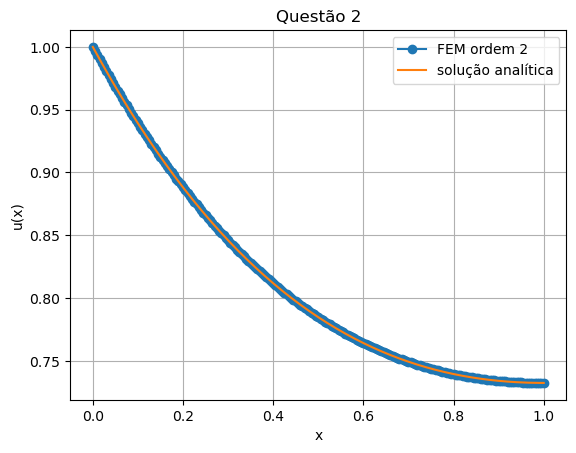

In [1]:
import numpy as np
import meshio
import matplotlib.pyplot as plt


def mat_elementar_q2(ordem, h, x_local, funf):
    """
    Monta a matriz elementar e o vetor elementar de carga
    para o problema

        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)

    Parâmetros
    ----------
    ordem : int
        Ordem do elemento finito:
        1 -> elemento linear
        2 -> elemento quadrático

    h : float
        Comprimento do elemento.

    x_local : ndarray
        Coordenadas dos nós locais do elemento.

    funf : callable
        Função do lado direito f(x).

    Retorna
    -------
    Aelem : ndarray
        Matriz elementar do problema:
            Aelem = 3*Kelem + 4*Melem

    belem : ndarray
        Vetor elementar de carga.
    """

    # -----------------------------------------
    # Elemento linear
    # -----------------------------------------
    if ordem == 1:
        # Matriz de rigidez local
        Kelem = (1.0 / h) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ], dtype=float)

        # Matriz de massa local
        Melem = (h / 6.0) * np.array([
            [2.0, 1.0],
            [1.0, 2.0]
        ], dtype=float)

    # -----------------------------------------
    # Elemento quadrático
    # -----------------------------------------
    elif ordem == 2:
        # Matriz de rigidez local para elemento
        # de Lagrange 1D de segunda ordem
        Kelem = (1.0 / (3.0 * h)) * np.array([
            [7.0, 1.0, -8.0],
            [1.0, 7.0, -8.0],
            [-8.0, -8.0, 16.0]
        ], dtype=float)

        # Matriz de massa local do elemento quadrático
        Melem = (h / 30.0) * np.array([
            [4.0, -1.0, 2.0],
            [-1.0, 4.0, 2.0],
            [2.0, 2.0, 16.0]
        ], dtype=float)

    else:
        raise ValueError("ordem deve ser 1 ou 2")

    # Matriz elementar do problema:
    # termo difusivo  -> 3*Kelem
    # termo reativo   -> 4*Melem
    Aelem = 3.0 * Kelem + 4.0 * Melem

    # Avalia a função fonte nos nós locais
    f_local = np.array([funf(xi) for xi in x_local], dtype=float)

    # Vetor de carga elementar.
    # Aqui seguimos a mesma ideia do código-base:
    # belem = Melem @ f_local
    belem = Melem @ f_local

    return Aelem, belem


def read_gmsh_1d(filename, ordem):
    """
    Lê um arquivo .msh do Gmsh usando meshio.

    Para ordem = 1, procura elementos do tipo 'line'.
    Para ordem = 2, procura elementos do tipo 'line3'.

    Retorna
    -------
    x : ndarray
        Coordenadas x dos nós.

    conec : ndarray
        Conectividade dos elementos 1D.
    """

    # Lê o arquivo de malha
    msh = meshio.read(filename)

    # Extrai a coordenada x dos nós
    x = msh.points[:, 0].copy()

    conec = None

    # -----------------------------------------
    # Caso linear: elementos do tipo "line"
    # -----------------------------------------
    if ordem == 1:
        for cell_block in msh.cells:
            if cell_block.type == "line":
                conec = np.array(cell_block.data, dtype=int)
                break

    # -----------------------------------------
    # Caso quadrático: elementos do tipo "line3"
    # -----------------------------------------
    elif ordem == 2:
        for cell_block in msh.cells:
            if cell_block.type == "line3":
                conec = np.array(cell_block.data, dtype=int)
                break

    else:
        raise ValueError("ordem deve ser 1 ou 2")

    # Se não encontrou o tipo certo de elemento, interrompe
    if conec is None:
        raise ValueError(
            f"Não encontrei elementos 1D do tipo esperado no arquivo .msh para ordem={ordem}."
        )

    return x, conec


def resolver_q2_gmsh(filename, ordem=1, tol=1e-12):
    """
    Resolve a Questão 2 lendo a malha de um arquivo .msh do Gmsh.

    Problema resolvido:
        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)
        u(0) = 1
        u'(1) = 0

    Retorna
    -------
    x_ord : ndarray
        Coordenadas ordenadas.

    uh_ord : ndarray
        Solução numérica ordenada.

    uh : ndarray
        Solução numérica no ordenamento original da malha.

    A : ndarray
        Matriz global do sistema.

    b : ndarray
        Vetor global do lado direito.
    """

    # Função fonte do problema
    funf = lambda x: 2.0 * np.exp(x - 1.0)

    # Lê a malha
    x, conec = read_gmsh_1d(filename, ordem)

    # Número de nós e número de elementos
    nnos = len(x)
    nelem = conec.shape[0]

    # Inicializa matriz global e vetor global
    A = np.zeros((nnos, nnos), dtype=float)
    b = np.zeros(nnos, dtype=float)

    # -----------------------------------------
    # Montagem do sistema global
    # -----------------------------------------
    for e in range(nelem):
        # Índices globais dos nós do elemento e
        nodes = conec[e]

        # Coordenadas dos nós locais do elemento
        x_local = x[nodes]

        # Comprimento do elemento
        h = abs(np.max(x_local) - np.min(x_local))

        # Matriz e vetor elementares
        Aelem, belem = mat_elementar_q2(ordem, h, x_local, funf)

        # Número de nós por elemento
        nen = len(nodes)

        # Soma das contribuições locais no sistema global
        for i in range(nen):
            I = nodes[i]
            b[I] += belem[i]

            for j in range(nen):
                J = nodes[j]
                A[I, J] += Aelem[i, j]

    # -----------------------------------------
    # Condição de Neumann: u'(1) = 0
    # -----------------------------------------
    # Como é homogênea, não gera termo adicional no vetor global.

    # -----------------------------------------
    # Condição de Dirichlet: u(0) = 1
    # -----------------------------------------
    dirichlet_nodes = np.where(np.abs(x - 0.0) < tol)[0]

    if len(dirichlet_nodes) == 0:
        raise ValueError("Não encontrei nó em x=0 para impor u(0)=1.")

    # Em geral, haverá só um nó em x=0
    for no in dirichlet_nodes:
        valor = 1.0

        # Ajusta o vetor do lado direito
        b -= A[:, no] * valor

        # Zera linha e coluna associadas ao nó de Dirichlet
        A[no, :] = 0.0
        A[:, no] = 0.0

        # Coloca 1 na diagonal principal
        A[no, no] = 1.0

        # Coloca o valor conhecido no vetor global
        b[no] = valor

    # Resolve o sistema linear
    uh = np.linalg.solve(A, b)

    # Ordena os nós por x para facilitar gráficos
    idx = np.argsort(x)
    x_ord = x[idx]
    uh_ord = uh[idx]

    return x_ord, uh_ord, uh, A, b


def solucao_analitica(x):
    """
    Retorna a solução analítica do problema da Questão 2.
    """

    alpha = 2.0 / np.sqrt(3.0)
    A = 1.0 - 2.0 / np.e
    B = -(2.0 + alpha * A * np.sinh(alpha)) / (alpha * np.cosh(alpha))

    return A * np.cosh(alpha * x) + B * np.sinh(alpha * x) + 2.0 * np.exp(x - 1.0)


if __name__ == "__main__":
    # -----------------------------------------
    # Arquivo de malha
    # -----------------------------------------
    arquivo_msh = "malhas_questoes_1-5/malha_1d.msh"

    # Ordem do elemento:
    # 1 -> linear
    # 2 -> quadrático
    ordem = 2

    # Resolve o problema numérico
    x, uh, _, _, _ = resolver_q2_gmsh(arquivo_msh, ordem=ordem)

    # Calcula a solução analítica nos mesmos pontos
    uex = solucao_analitica(x)

    # Calcula o erro na norma do infinito
    erro_inf = np.max(np.abs(uh - uex))

    # Mostra resultados no terminal
    print("x =", x)
    print("u_h =", uh)
    print("erro infinito =", erro_inf)

    # -----------------------------------------
    # Gráfico da solução numérica e analítica
    # -----------------------------------------
    plt.plot(x, uh, "o-", label=f"FEM ordem {ordem}")
    plt.plot(x, uex, "-", label="solução analítica")
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.title("Questão 2")
    plt.grid(True)
    plt.legend()
    plt.show()

<hr>
<h3><font color='#79191E'>Questão 3</font></h3>

A equação diferencial é
$$
-3u''(x)+4u(x)=2e^{x-1}.
$$

A equação homogênea associada é
$$
-3u''+4u=0.
$$

Buscando solução da forma $u=e^{rx}$, obtemos
$$
-3r^2+4=0
\quad\Rightarrow\quad
r=\pm\frac{2}{\sqrt{3}}.
$$

Logo, a solução homogênea é
$$
u_h(x)=C_1 e^{\frac{2}{\sqrt{3}}x}+C_2 e^{-\frac{2}{\sqrt{3}}x}.
$$

Para uma solução particular, tentamos
$$
u_p(x)=Ae^{x-1}.
$$

Então
$$
u_p''(x)=Ae^{x-1},
$$
e substituindo na equação:
$$
-3Ae^{x-1}+4Ae^{x-1}=2e^{x-1}.
$$

Daí segue que
$$
A=2,
$$
portanto
$$
u_p(x)=2e^{x-1}.
$$

Assim, a solução geral é
$$
u(x)=C_1 e^{\frac{2}{\sqrt{3}}x}+C_2 e^{-\frac{2}{\sqrt{3}}x}+2e^{x-1}.
$$

Aplicando a condição $u(0)=1$, obtemos
$$
C_1+C_2+\frac{2}{e}=1,
$$
isto é,
$$
C_1+C_2=1-\frac{2}{e}.
$$

Derivando,
$$
u'(x)=\frac{2}{\sqrt{3}}C_1 e^{\frac{2}{\sqrt{3}}x}
-\frac{2}{\sqrt{3}}C_2 e^{-\frac{2}{\sqrt{3}}x}
+2e^{x-1}.
$$

Usando a condição $u'(1)=0$, segue que
$$
\frac{2}{\sqrt{3}}C_1 e^{\frac{2}{\sqrt{3}}}
-\frac{2}{\sqrt{3}}C_2 e^{-\frac{2}{\sqrt{3}}}
+2=0.
$$

Definindo
$$
\alpha=\frac{2}{\sqrt{3}},
$$
o sistema fica
$$
C_1+C_2=1-\frac{2}{e},
$$
$$
\alpha C_1 e^{\alpha}-\alpha C_2 e^{-\alpha}=-2.
$$

Substituindo
$$
C_2=1-\frac{2}{e}-C_1
$$
na segunda equação, obtemos
$$
\alpha C_1(e^\alpha+e^{-\alpha})
=
-2+\alpha\left(1-\frac{2}{e}\right)e^{-\alpha}.
$$

Logo,
$$
C_1=
\frac{-2+\alpha\left(1-\frac{2}{e}\right)e^{-\alpha}}
{\alpha\left(e^\alpha+e^{-\alpha}\right)},
$$

e
$$
C_2=
1-\frac{2}{e}
-
\frac{-2+\alpha\left(1-\frac{2}{e}\right)e^{-\alpha}}
{\alpha\left(e^\alpha+e^{-\alpha}\right)}.
$$

Portanto, a solução analítica é
$$\boxed{
u(x)=C_1 e^{\frac{2}{\sqrt{3}}x}+C_2 e^{-\frac{2}{\sqrt{3}}x}+2e^{x-1}}\,.
$$

<hr>
<h3><font color='#79191E'>Questão 4-5</font></h3>

O código abaixo é utilizado para conferir o conteúdo dos arquivos de malha gerados no Gmsh. Esse comando lê cada arquivo $\texttt{.msh}$ com a biblioteca $\texttt{meshio}$ e mostra os tipos de elementos armazenados na malha, bem como a quantidade de elementos de cada tipo. Com isso, foi possível verificar que a malha linear possuía elementos do tipo $\texttt{line}$ e que a malha quadrática possuía elementos do tipo $\texttt{line3}$.

In [2]:
import meshio

for arquivo in ["malhas_questoes_1-5/malha_linear.msh", "malhas_questoes_1-5/malha_quadratica.msh"]:
    msh = meshio.read(arquivo)
    print("\nArquivo:", arquivo)
    for c in msh.cells:
        print("  tipo:", c.type, " quantidade:", len(c.data))



Arquivo: malhas_questoes_1-5/malha_linear.msh
  tipo: vertex  quantidade: 1
  tipo: vertex  quantidade: 1
  tipo: line  quantidade: 100


Arquivo: malhas_questoes_1-5/malha_quadratica.msh
  tipo: vertex  quantidade: 1
  tipo: vertex  quantidade: 1
  tipo: line3  quantidade: 100


Versão do código em Python:



=== Elementos lineares ===
Erro infinito = 6.483629373388311e-07

=== Elementos quadráticos ===
Erro infinito = 1.7606360813715582e-11


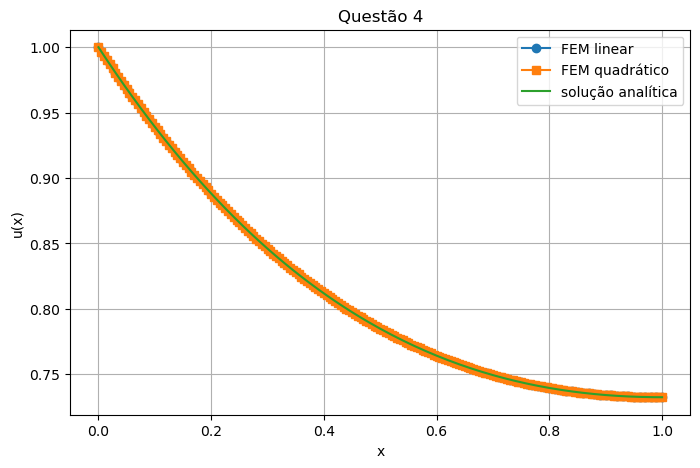

In [3]:
import numpy as np
import meshio
import matplotlib.pyplot as plt


def mat_elementar_q4(ordem, h, x_local, funf):
    """
    Monta a matriz elementar e o vetor elementar de carga
    para o problema:

        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)

    Parâmetros
    ----------
    ordem : int
        Ordem do elemento:
        1 -> elemento linear
        2 -> elemento quadrático

    h : float
        Tamanho do elemento.

    x_local : array
        Coordenadas dos nós locais do elemento.

    funf : função
        Função do lado direito f(x).

    Retorna
    -------
    Aelem : ndarray
        Matriz elementar do problema:
            Aelem = 3*Kelem + 4*Melem

    belem : ndarray
        Vetor elementar de carga.
    """

    # -----------------------------
    # Caso 1: elemento linear
    # -----------------------------
    if ordem == 1:
        # Matriz de rigidez local:
        # integral de dNi/dx * dNj/dx
        Kelem = (1.0 / h) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ], dtype=float)

        # Matriz de massa local:
        # integral de Ni * Nj
        Melem = (h / 6.0) * np.array([
            [2.0, 1.0],
            [1.0, 2.0]
        ], dtype=float)

    # -----------------------------
    # Caso 2: elemento quadrático
    # -----------------------------
    elif ordem == 2:
        # Matriz de rigidez local para elemento de Lagrange 1D de segunda ordem
        Kelem = (1.0 / (3.0 * h)) * np.array([
            [7.0, 1.0, -8.0],
            [1.0, 7.0, -8.0],
            [-8.0, -8.0, 16.0]
        ], dtype=float)

        # Matriz de massa local para elemento quadrático
        Melem = (h / 30.0) * np.array([
            [4.0, -1.0, 2.0],
            [-1.0, 4.0, 2.0],
            [2.0, 2.0, 16.0]
        ], dtype=float)

    else:
        raise ValueError("ordem deve ser 1 ou 2")

    # Matriz elementar do problema:
    # termo difusivo  -> 3*Kelem
    # termo reativo   -> 4*Melem
    Aelem = 3.0 * Kelem + 4.0 * Melem

    # Avalia a função fonte nos nós locais do elemento
    f_local = np.array([funf(xi) for xi in x_local], dtype=float)

    # Aproxima o vetor de carga elementar pela mesma ideia do código do professor:
    # belem = Melem * f_local
    belem = Melem @ f_local

    return Aelem, belem


def read_gmsh_1d(filename, ordem):
    """
    Lê um arquivo .msh gerado pelo Gmsh e extrai:

    - coordenadas x dos nós
    - conectividade dos elementos 1D

    Para ordem = 1, procura elementos do tipo 'line'.
    Para ordem = 2, procura elementos do tipo 'line3'.
    """

    # Lê a malha com meshio
    msh = meshio.read(filename)

    # Coordenadas x de todos os nós
    x = msh.points[:, 0].copy()

    conec = None

    # Para elementos lineares, o Gmsh salva como "line"
    if ordem == 1:
        for cell_block in msh.cells:
            if cell_block.type == "line":
                conec = np.array(cell_block.data, dtype=int)
                break

    # Para elementos quadráticos, o Gmsh salva como "line3"
    elif ordem == 2:
        for cell_block in msh.cells:
            if cell_block.type == "line3":
                conec = np.array(cell_block.data, dtype=int)
                break

    # Se não encontrou o tipo correto, gera erro
    if conec is None:
        raise ValueError(
            f"Não encontrei elementos compatíveis com ordem={ordem} no arquivo {filename}."
        )

    return x, conec


def resolver_bvp_gmsh(filename, ordem=1, tol=1e-12):
    """
    Resolve o problema de valor de contorno:

        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)
        u(0) = 1
        u'(1) = 0

    usando uma malha lida de um arquivo .msh do Gmsh.
    """

    # Define a função do lado direito
    funf = lambda x: 2.0 * np.exp(x - 1.0)

    # Lê coordenadas dos nós e conectividade da malha
    x, conec = read_gmsh_1d(filename, ordem)

    # Número total de nós
    nnos = len(x)

    # Número de elementos
    nelem = conec.shape[0]

    # Inicializa matriz global e vetor global
    A = np.zeros((nnos, nnos), dtype=float)
    b = np.zeros(nnos, dtype=float)

    # -----------------------------
    # Montagem global
    # -----------------------------
    for e in range(nelem):
        # Nós globais do elemento e
        nodes = conec[e]

        # Coordenadas locais do elemento
        x_local = x[nodes]

        # Tamanho do elemento
        h = np.max(x_local) - np.min(x_local)

        # Monta matriz e vetor elementares
        Aelem, belem = mat_elementar_q4(ordem, h, x_local, funf)

        # Número de nós no elemento
        nen = len(nodes)

        # Soma das contribuições locais na matriz e no vetor globais
        for i in range(nen):
            I = nodes[i]
            b[I] += belem[i]

            for j in range(nen):
                J = nodes[j]
                A[I, J] += Aelem[i, j]

    # -----------------------------
    # Condição de Dirichlet: u(0)=1
    # -----------------------------
    dirichlet_nodes = np.where(np.abs(x - 0.0) < tol)[0]

    if len(dirichlet_nodes) == 0:
        raise ValueError("Não encontrei nó em x=0 para impor u(0)=1.")

    # Impõe a condição de contorno diretamente no sistema
    for no in dirichlet_nodes:
        valor = 1.0

        # Ajusta o vetor do lado direito
        b -= A[:, no] * valor

        # Zera linha e coluna correspondentes ao nó de Dirichlet
        A[no, :] = 0.0
        A[:, no] = 0.0

        # Coloca 1 na diagonal principal
        A[no, no] = 1.0

        # Coloca o valor conhecido no vetor global
        b[no] = valor

    # -----------------------------
    # Condição de Neumann: u'(1)=0
    # -----------------------------
    # Como a condição é homogênea, não entra termo adicional no vetor global.

    # Resolve o sistema linear
    uh = np.linalg.solve(A, b)

    # Ordena os nós pelo valor de x para facilitar gráficos e comparação
    idx = np.argsort(x)

    return x[idx], uh[idx]


def solucao_analitica(x):
    """
    Retorna a solução analítica do problema.

    A solução foi obtida resolvendo a EDO:
        -3u'' + 4u = 2 exp(x-1)
    com
        u(0)=1
        u'(1)=0
    """

    alpha = 2.0 / np.sqrt(3.0)

    A = 1.0 - 2.0 / np.e
    B = -(2.0 + alpha * A * np.sinh(alpha)) / (alpha * np.cosh(alpha))

    return A * np.cosh(alpha * x) + B * np.sinh(alpha * x) + 2.0 * np.exp(x - 1.0)


if __name__ == "__main__":
    # ---------------------------------------
    # Arquivos de malha gerados no Gmsh
    # ---------------------------------------
    arquivo_linear = "malhas_questoes_1-5/malha_linear.msh"
    arquivo_quadratica = "malhas_questoes_1-5/malha_quadratica.msh"

    # ---------------------------------------
    # Resolve com elementos lineares
    # ---------------------------------------
    x_lin, uh_lin = resolver_bvp_gmsh(arquivo_linear, ordem=1)

    # ---------------------------------------
    # Resolve com elementos quadráticos
    # ---------------------------------------
    x_quad, uh_quad = resolver_bvp_gmsh(arquivo_quadratica, ordem=2)

    # ---------------------------------------
    # Calcula a solução analítica nos nós
    # ---------------------------------------
    uex_lin = solucao_analitica(x_lin)
    uex_quad = solucao_analitica(x_quad)

    # ---------------------------------------
    # Calcula o erro na norma do infinito
    # ---------------------------------------
    erro_lin = np.max(np.abs(uh_lin - uex_lin))
    erro_quad = np.max(np.abs(uh_quad - uex_quad))

    print("=== Elementos lineares ===")
    print("Erro infinito =", erro_lin)

    print("\n=== Elementos quadráticos ===")
    print("Erro infinito =", erro_quad)

    # ---------------------------------------
    # Gráfico das soluções
    # ---------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(x_lin, uh_lin, "o-", label="FEM linear")
    plt.plot(x_quad, uh_quad, "s-", label="FEM quadrático")
    plt.plot(x_quad, uex_quad, "-", label="solução analítica")

    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.title("Questão 4")
    plt.grid(True)
    plt.legend()
    plt.show()

<hr>
<h3><font color='#79191E'>Questão 6</font></h3>

Para a Questão 6, o problema foi resolvido em três níveis de refinamento: uma malha com tamanho aproximadamente $h$, outra com tamanho aproximadamente $h/2$ e outra com tamanho aproximadamente $h/10$. Em cada caso, foram utilizados elementos lineares e elementos quadráticos.

Os erros na norma do infinito diminuíram à medida que a malha foi refinada, tanto para elementos lineares quanto para elementos quadráticos. Além disso, os elementos quadráticos apresentaram erros significativamente menores que os elementos lineares para níveis de refinamento comparáveis.

As razões entre os erros ficaram próximas do comportamento teórico esperado. Para elementos lineares, espera-se convergência de ordem aproximadamente $2$, isto é,
$$
\|u-u_h\|_\infty = O(h^2),
$$
de modo que, ao passar de $h$ para $h/2$, a razão esperada é próxima de $4$, e ao passar de $h$ para $h/10$, próxima de $100$.

Para elementos quadráticos, espera-se convergência de ordem aproximadamente $3$, isto é,
$$
\|u-u_h\|_\infty = O(h^3),
$$
de modo que as razões esperadas são próximas de $8$ para a passagem de $h$ para $h/2$, e próximas de $1000$ para a passagem de $h$ para $h/10$.

Portanto, a redução do erro com o refinamento da malha está de acordo com o esperado teoricamente.








=== Elementos lineares ===
Malha    h            Erro infinito      Razão vs anterior 
h        0.100000     6.5102949485e-05   -                 
h/2      0.050000     1.6217876801e-05   4.014271          
h/10     0.010000     6.4836293734e-07   25.013578         

=== Elementos quadráticos ===
Malha    h            Erro infinito      Razão vs anterior 
h        0.050000     1.4868997111e-07   -                 
h/2      0.025000     9.6673461458e-09   15.380640         
h/10     0.005000     1.7606360814e-11   549.082587        

=== Razões tomando a malha h como referência ===
Linear:     E(h)/E(h/2)  = 4.014271
Linear:     E(h)/E(h/10) = 100.411275
Quadrático: E(h)/E(h/2)  = 15.380640
Quadrático: E(h)/E(h/10) = 8445.241620


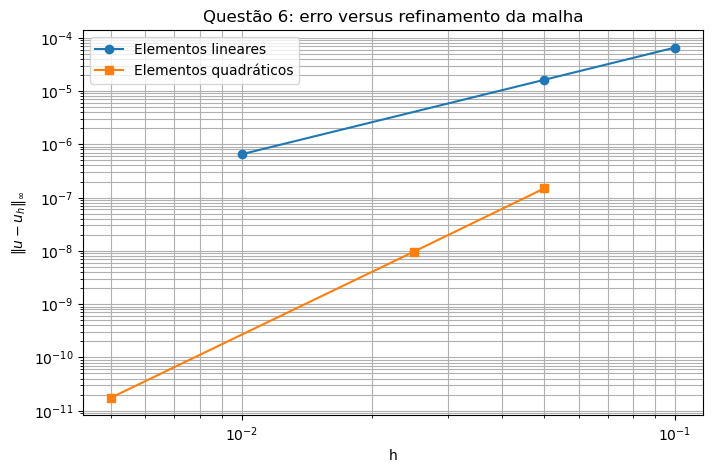

In [4]:
import numpy as np
import meshio
import matplotlib.pyplot as plt


def mat_elementar(ordem, h, x_local, funf):
    """
    Monta a matriz elementar e o vetor elementar de carga
    para o problema

        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)

    Parâmetros
    ----------
    ordem : int
        Ordem do elemento finito:
        1 -> elemento linear
        2 -> elemento quadrático

    h : float
        Tamanho do elemento.

    x_local : ndarray
        Coordenadas dos nós locais do elemento.

    funf : callable
        Função fonte f(x).

    Retorna
    -------
    Aelem : ndarray
        Matriz elementar do problema:
            Aelem = 3*Kelem + 4*Melem

    belem : ndarray
        Vetor elementar de carga.
    """

    # -----------------------------------------
    # Elemento linear
    # -----------------------------------------
    if ordem == 1:
        # Matriz de rigidez local
        Kelem = (1.0 / h) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ], dtype=float)

        # Matriz de massa local
        Melem = (h / 6.0) * np.array([
            [2.0, 1.0],
            [1.0, 2.0]
        ], dtype=float)

    # -----------------------------------------
    # Elemento quadrático
    # -----------------------------------------
    elif ordem == 2:
        # Matriz de rigidez local para elemento
        # de Lagrange 1D de segunda ordem
        Kelem = (1.0 / (3.0 * h)) * np.array([
            [7.0, 1.0, -8.0],
            [1.0, 7.0, -8.0],
            [-8.0, -8.0, 16.0]
        ], dtype=float)

        # Matriz de massa local para elemento quadrático
        Melem = (h / 30.0) * np.array([
            [4.0, -1.0, 2.0],
            [-1.0, 4.0, 2.0],
            [2.0, 2.0, 16.0]
        ], dtype=float)

    else:
        raise ValueError("ordem deve ser 1 ou 2")

    # Matriz elementar final do problema:
    # termo difusivo: 3*Kelem
    # termo reativo : 4*Melem
    Aelem = 3.0 * Kelem + 4.0 * Melem

    # Avalia a função fonte nos nós locais do elemento
    f_local = np.array([funf(xi) for xi in x_local], dtype=float)

    # Vetor de carga elementar
    # Aqui usamos a mesma ideia do código-base:
    # belem = Melem @ f_local
    belem = Melem @ f_local

    return Aelem, belem


def read_gmsh_1d(filename, ordem):
    """
    Lê um arquivo .msh do Gmsh e extrai:
    - as coordenadas x dos nós;
    - a conectividade dos elementos 1D.

    Para ordem 1, procura elementos do tipo 'line'.
    Para ordem 2, procura elementos do tipo 'line3'.
    """

    # Lê o arquivo de malha
    msh = meshio.read(filename)

    # Extrai a coordenada x de cada nó
    x = msh.points[:, 0].copy()

    # Define o tipo de elemento esperado
    tipo_esperado = "line" if ordem == 1 else "line3"
    conec = None

    # Percorre os blocos de elementos da malha
    for cell_block in msh.cells:
        if cell_block.type == tipo_esperado:
            conec = np.array(cell_block.data, dtype=int)
            break

    # Se não encontrar o tipo correto, interrompe com erro
    if conec is None:
        raise ValueError(
            f"Não encontrei elementos {tipo_esperado} no arquivo {filename}."
        )

    return x, conec


def resolver_bvp_gmsh(filename, ordem=1, tol=1e-12):
    """
    Resolve o problema de valor de contorno

        -3u''(x) + 4u(x) = 2 exp(x-1),   x em (0,1)
        u(0) = 1
        u'(1) = 0

    a partir de uma malha lida de um arquivo .msh do Gmsh.

    Retorna
    -------
    x_ord : ndarray
        Coordenadas dos nós ordenadas.

    uh_ord : ndarray
        Solução numérica ordenada nas coordenadas x.
    """

    # Função do lado direito
    funf = lambda x: 2.0 * np.exp(x - 1.0)

    # Lê a malha
    x, conec = read_gmsh_1d(filename, ordem)

    # Número de nós e número de elementos
    nnos = len(x)
    nelem = conec.shape[0]

    # Inicializa matriz global e vetor global
    A = np.zeros((nnos, nnos), dtype=float)
    b = np.zeros(nnos, dtype=float)

    # -----------------------------------------
    # Montagem do sistema global
    # -----------------------------------------
    for e in range(nelem):
        # Índices globais dos nós do elemento e
        nodes = conec[e]

        # Coordenadas locais do elemento
        x_local = x[nodes]

        # Comprimento do elemento
        h = np.max(x_local) - np.min(x_local)

        # Matriz e vetor elementares
        Aelem, belem = mat_elementar(ordem, h, x_local, funf)

        nen = len(nodes)  # número de nós do elemento

        # Soma das contribuições locais no sistema global
        for i in range(nen):
            I = nodes[i]
            b[I] += belem[i]

            for j in range(nen):
                J = nodes[j]
                A[I, J] += Aelem[i, j]

    # -----------------------------------------
    # Condição de Dirichlet: u(0) = 1
    # -----------------------------------------
    dirichlet_nodes = np.where(np.abs(x - 0.0) < tol)[0]

    if len(dirichlet_nodes) == 0:
        raise ValueError(f"Não encontrei nó em x=0 no arquivo {filename}.")

    # Impõe a condição diretamente no sistema linear
    for no in dirichlet_nodes:
        valor = 1.0

        # Ajusta o vetor do lado direito
        b -= A[:, no] * valor

        # Zera a linha e a coluna do nó
        A[no, :] = 0.0
        A[:, no] = 0.0

        # Coloca 1 na diagonal e o valor conhecido em b
        A[no, no] = 1.0
        b[no] = valor

    # -----------------------------------------
    # Condição de Neumann: u'(1) = 0
    # -----------------------------------------
    # Como é homogênea, não gera termo adicional no vetor global.

    # Resolve o sistema linear
    uh = np.linalg.solve(A, b)

    # Ordena os nós pelo valor de x para facilitar comparação e gráficos
    idx = np.argsort(x)

    return x[idx], uh[idx]


def solucao_analitica(x):
    """
    Retorna a solução analítica do problema.
    """

    alpha = 2.0 / np.sqrt(3.0)
    A = 1.0 - 2.0 / np.e
    B = -(2.0 + alpha * A * np.sinh(alpha)) / (alpha * np.cosh(alpha))

    return A * np.cosh(alpha * x) + B * np.sinh(alpha * x) + 2.0 * np.exp(x - 1.0)


def erro_infinito(x, uh):
    """
    Calcula o erro na norma do infinito:
        ||u - uh||_inf = max |u(x_i) - uh(x_i)|
    """
    uex = solucao_analitica(x)
    return np.max(np.abs(uh - uex))


def estimar_h(x):
    """
    Estima o tamanho de malha a partir das coordenadas dos nós.

    Observação:
    para elementos quadráticos, esse valor pode corresponder
    à menor distância entre nós consecutivos e não necessariamente
    ao comprimento total do elemento geométrico.
    """
    x_ord = np.sort(np.unique(x))
    hs = np.diff(x_ord)
    return np.max(hs)


def rodar_caso(rotulo, arquivo, ordem):
    """
    Executa um caso de teste:
    - resolve o problema em uma malha dada;
    - calcula o erro;
    - estima o tamanho da malha.

    Retorna um dicionário com os resultados.
    """
    x, uh = resolver_bvp_gmsh(arquivo, ordem=ordem)
    erro = erro_infinito(x, uh)
    h = estimar_h(x)

    return {
        "rotulo": rotulo,
        "arquivo": arquivo,
        "ordem": ordem,
        "x": x,
        "uh": uh,
        "erro": erro,
        "h": h,
    }


def imprimir_resultados(nome_tipo, resultados):
    """
    Imprime uma tabela com:
    - nome da malha;
    - valor estimado de h;
    - erro infinito;
    - razão do erro em relação ao caso anterior.
    """
    print(f"\n=== {nome_tipo} ===")
    print(f"{'Malha':<8} {'h':<12} {'Erro infinito':<18} {'Razão vs anterior':<18}")

    erro_anterior = None
    for r in resultados:
        if erro_anterior is None:
            razao = "-"
        else:
            razao = f"{erro_anterior / r['erro']:.6f}"

        print(f"{r['rotulo']:<8} {r['h']:<12.6f} {r['erro']:<18.10e} {razao:<18}")
        erro_anterior = r["erro"]


if __name__ == "__main__":
    # Pasta onde estão as malhas da Questão 6
    base = "malhas_questoes_6"

    # -----------------------------------------
    # Malhas lineares
    # -----------------------------------------
    malhas_lineares = [
        ("h",    f"{base}/malha_linear_h.msh"),
        ("h/2",  f"{base}/malha_linear_h2.msh"),
        ("h/10", f"{base}/malha_linear_h10.msh"),
    ]

    # -----------------------------------------
    # Malhas quadráticas
    # -----------------------------------------
    malhas_quadraticas = [
        ("h",    f"{base}/malha_quadratica_h.msh"),
        ("h/2",  f"{base}/malha_quadratica_h2.msh"),
        ("h/10", f"{base}/malha_quadratica_h10.msh"),
    ]

    # Executa todos os casos lineares
    resultados_lineares = [
        rodar_caso(rotulo, arquivo, ordem=1)
        for rotulo, arquivo in malhas_lineares
    ]

    # Executa todos os casos quadráticos
    resultados_quadraticos = [
        rodar_caso(rotulo, arquivo, ordem=2)
        for rotulo, arquivo in malhas_quadraticas
    ]

    # Imprime tabelas de resultados
    imprimir_resultados("Elementos lineares", resultados_lineares)
    imprimir_resultados("Elementos quadráticos", resultados_quadraticos)

    # -----------------------------------------
    # Razões de erro tomando a malha h como referência
    # -----------------------------------------
    E_lin_h = resultados_lineares[0]["erro"]
    E_lin_h2 = resultados_lineares[1]["erro"]
    E_lin_h10 = resultados_lineares[2]["erro"]

    E_quad_h = resultados_quadraticos[0]["erro"]
    E_quad_h2 = resultados_quadraticos[1]["erro"]
    E_quad_h10 = resultados_quadraticos[2]["erro"]

    print("\n=== Razões tomando a malha h como referência ===")
    print(f"Linear:     E(h)/E(h/2)  = {E_lin_h / E_lin_h2:.6f}")
    print(f"Linear:     E(h)/E(h/10) = {E_lin_h / E_lin_h10:.6f}")
    print(f"Quadrático: E(h)/E(h/2)  = {E_quad_h / E_quad_h2:.6f}")
    print(f"Quadrático: E(h)/E(h/10) = {E_quad_h / E_quad_h10:.6f}")

    # -----------------------------------------
    # Gráfico do erro em função de h
    # -----------------------------------------
    h_lin = np.array([r["h"] for r in resultados_lineares], dtype=float)
    err_lin = np.array([r["erro"] for r in resultados_lineares], dtype=float)

    h_quad = np.array([r["h"] for r in resultados_quadraticos], dtype=float)
    err_quad = np.array([r["erro"] for r in resultados_quadraticos], dtype=float)

    plt.figure(figsize=(8, 5))
    plt.loglog(h_lin, err_lin, "o-", label="Elementos lineares")
    plt.loglog(h_quad, err_quad, "s-", label="Elementos quadráticos")
    plt.xlabel("h")
    plt.ylabel(r"$\|u-u_h\|_\infty$")
    plt.title("Questão 6: erro versus refinamento da malha")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()